# ANÁLISIS ESTADÍSTICO — FEATURES DE VIDEO — FINGER TAPPING MDS-UPDRS 3.4
## Pipeline: Carga → Descriptivo → Inferencial → Correlación → Exportación

**Estructura del pipeline:**
1. Carga y merge de features y diagnóstico
2. Análisis descriptivo por score
3. Análisis inferencial (Kruskal-Wallis + post-hoc)
4. Correlación Spearman feature vs score
5. Exportación final (CSV + Excel)

**Dataset:**
Videos procesados con MediaPipe HandLandmarker; se extraen features classical del pipeline de video y los scores corresponden a UPDRS 0–4.

---
## CELDA 1 — Imports y configuración

In [1]:
"""
============================================================================
IMPORTS Y CONFIGURACIÓN GLOBAL
Define rutas, paleta de colores y parámetros base del análisis.
============================================================================
"""

import os
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.stats import kruskal, mannwhitneyu, spearmanr
from itertools import combinations

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ─────────────────────────────────────────────
# CONFIGURACIÓN — ajustar parámetros aquí
# ─────────────────────────────────────────────
class Config:
    # Identificador del dataset
    DATASET_ID = "fis"

    # Rutas de entrada
    RUTA_FEATURES = f"../output_files/{DATASET_ID}_classical_features.csv"
    RUTA_DIAGNOSTICO = f"../input_files/{DATASET_ID}_diagnostic.csv"

    # Carpeta de salida
    RUTA_SALIDA = "../results_files/analisis_estadistico"

    # Paleta de colores
    SCORE_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}
    SCORE_LABELS = {0:'Score 0\n(Sano)', 1:'Score 1', 2:'Score 2', 3:'Score 3', 4:'Score 4'}

    # Significancia estadística
    ALPHA = 0.05

    # Features a visualizar
    FEATURES_PLOT = [
        'SMOOTHED_AMPLITUDE_mean', 'SMOOTHED_AMPLITUDE_std',
        'VELOCITY_mean', 'FREQUENCY_mean', 'INTERVAL_CV',
        'ITI_MEAN', 'ITI_STD', 'JERK_RMS', 'DISTANCE_ANG_mean'
    ]

    LABELS_PLOT = [
        'Amplitud media (norm.)', 'Std Amplitud', 'Velocidad media',
        'Frecuencia media (Hz)', 'CV Intervalo', 'ITI medio (s)',
        'Std ITI (s)', 'Jerk RMS', 'Ángulo medio (norm.)'
    ]

    # Se asigna dinámicamente al cargar el dataset
    FEATURES_ANALISIS = []

os.makedirs(Config.RUTA_SALIDA, exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/figuras", exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/tablas", exist_ok=True)

print("✅ Configuración cargada")
print(f"   Dataset ID : {Config.DATASET_ID}")
print(f"   Ruta salida: {Config.RUTA_SALIDA}")
print(f"   Features plot: {len(Config.FEATURES_PLOT)}")

✅ Configuración cargada
   Dataset ID : fis
   Ruta salida: ../results_files/analisis_estadistico
   Features plot: 9


---
## CELDA 2 — Carga y merge del dataset

In [2]:
"""
============================================================================
CARGA Y PREPARACIÓN DEL DATASET DE VIDEO
A diferencia del IMU (múltiples registros por sujeto), cada fila aquí
representa un video único y el ID es el nombre del archivo de video.
============================================================================
"""

# 1. Cargar CSV de features
df_features = pd.read_csv(Config.RUTA_FEATURES)
if 'Unnamed: 0' in df_features.columns:
    df_features = df_features.rename(columns={'Unnamed: 0': 'ID'})
elif 'ID' not in df_features.columns:
    df_features = df_features.rename(columns={df_features.columns[0]: 'ID'})
df_features['ID'] = df_features['ID'].astype(str)

# 2. Cargar CSV de diagnóstico
df_diag = pd.read_csv(Config.RUTA_DIAGNOSTICO, dtype={'ID': str})
if 'UPDRS' in df_diag.columns:
    df_diag['UPDRS'] = df_diag['UPDRS'].astype(int)
else:
    df_diag['UPDRS'] = pd.to_numeric(df_diag.iloc[:, 1], errors='coerce').astype('Int64')
    df_diag = df_diag.rename(columns={df_diag.columns[1]: 'UPDRS'})
df_diag['ID'] = df_diag['ID'].astype(str)

# 3. Merge inner por ID
df_master = pd.merge(df_features, df_diag, on='ID', how='inner')

# 4. Renombrar UPDRS a score
df_master = df_master.rename(columns={'UPDRS': 'score'})

# 5. Asignar features disponibles
Config.FEATURES_ANALISIS = [c for c in df_master.columns if c not in ['ID', 'score']]

# 6. Resumen del dataset
print(f"Shape del dataset: {df_master.shape}")
print("Distribución de scores:")
print(df_master['score'].value_counts().sort_index().to_string())
print(f"N features disponibles: {len(Config.FEATURES_ANALISIS)}")

nan_pct = (df_master[Config.FEATURES_ANALISIS].isna().mean() * 100).sort_values(ascending=False)
nan_pct = nan_pct[nan_pct > 5]
if len(nan_pct) > 0:
    print("\n⚠️ Features con >5% NaN:")
    print(nan_pct.to_string())
else:
    print("\nSin features con >5% NaN")

# 7. Guardar dataset maestro
csv_master = f"{Config.RUTA_SALIDA}/tablas/dataset_maestro_video.csv"
df_master.to_csv(csv_master, index=False)
print(f"💾 Dataset maestro guardado: {csv_master}")

Shape del dataset: (220, 33)
Distribución de scores:
score
0    68
1    96
2    33
3    23
N features disponibles: 31

Sin features con >5% NaN
💾 Dataset maestro guardado: ../results_files/analisis_estadistico/tablas/dataset_maestro_video.csv


---
## CELDA 3 — Análisis descriptivo

In [3]:
"""
============================================================================
ANÁLISIS DESCRIPTIVO — Mediana, IQR y estadísticos por score
============================================================================
"""

scores_presentes = sorted(df_master['score'].dropna().unique().tolist())

rows = []
for score in scores_presentes:
    sub = df_master[df_master['score'] == score]
    for feat in Config.FEATURES_ANALISIS:
        v = sub[feat].dropna()
        rows.append({
            'score': score,
            'feature': feat,
            'n': len(v),
            'mediana': np.median(v) if len(v) > 0 else np.nan,
            'IQR': np.percentile(v, 75) - np.percentile(v, 25) if len(v) > 0 else np.nan,
            'media': np.mean(v) if len(v) > 0 else np.nan,
            'std': np.std(v) if len(v) > 0 else np.nan
        })

df_descriptivo = pd.DataFrame(rows)

pivot = df_descriptivo[df_descriptivo['feature'].isin(Config.FEATURES_PLOT)].pivot_table(
    index='feature', columns='score', values='mediana', aggfunc='first'
).round(3)
print(pivot.to_string())

csv_desc = f"{Config.RUTA_SALIDA}/tablas/descriptivo_video_por_score.csv"
df_descriptivo.to_csv(csv_desc, index=False)
print(f"💾 Descriptivo guardado: {csv_desc}")

score                          0        1        2        3
feature                                                    
DISTANCE_ANG_mean          0.200    0.174    0.164    0.093
FREQUENCY_mean             1.815    1.873    1.896    1.959
INTERVAL_CV                0.120    0.269    0.304    0.284
ITI_MEAN                   0.573    0.563    0.568    0.557
ITI_STD                    0.065    0.152    0.170    0.156
JERK_RMS                 957.206  842.159  790.263  432.130
SMOOTHED_AMPLITUDE_mean    0.342    0.319    0.308    0.209
SMOOTHED_AMPLITUDE_std     0.173    0.135    0.166    0.074
VELOCITY_mean              0.001   -0.001    0.000   -0.002
💾 Descriptivo guardado: ../results_files/analisis_estadistico/tablas/descriptivo_video_por_score.csv


---
## CELDA 4 — Boxplots por score

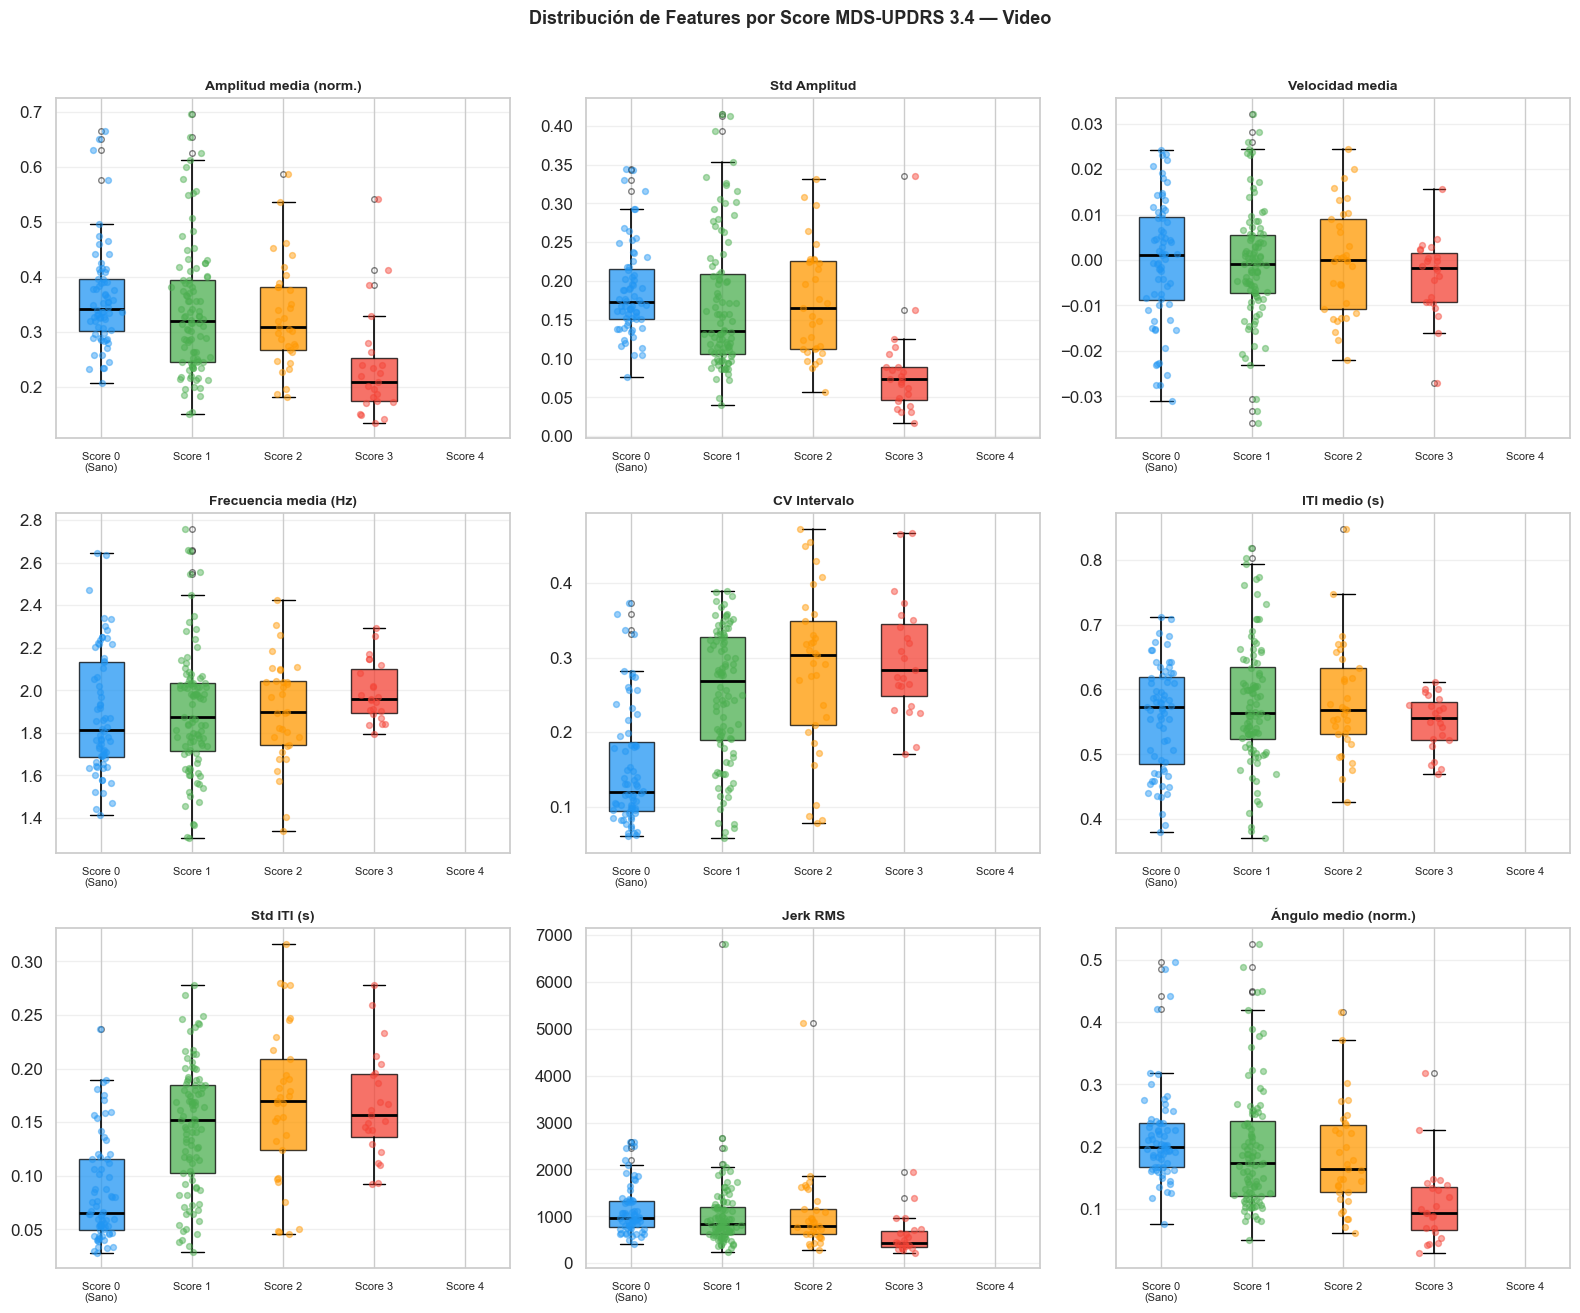

💾 Boxplots guardados


In [4]:
"""
============================================================================
VISUALIZACIÓN — Boxplots de features por score UPDRS
============================================================================
"""

scores_orden = list(Config.SCORE_LABELS.keys())

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(Config.FEATURES_PLOT, Config.LABELS_PLOT)):
    ax = axes[i]
    data_por_score = [
        df_master[df_master['score'] == s][feat].dropna().values
        for s in scores_orden
    ]

    bp = ax.boxplot(
        data_por_score,
        labels=[Config.SCORE_LABELS[s] for s in scores_orden],
        patch_artist=True, notch=False,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=4, alpha=0.5)
    )

    for patch, score in zip(bp['boxes'], scores_orden):
        patch.set_facecolor(Config.SCORE_COLORS.get(score, '#BDBDBD'))
        patch.set_alpha(0.75)

    for j, (datos, score) in enumerate(zip(data_por_score, scores_orden)):
        x = np.random.normal(j + 1, 0.07, size=len(datos))
        ax.scatter(x, datos, alpha=0.45, s=18,
                   color=Config.SCORE_COLORS.get(score, '#BDBDBD'), zorder=5)

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribución de Features por Score MDS-UPDRS 3.4 — Video',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/descriptivo_boxplots_video.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("💾 Boxplots guardados")

---
## CELDA 5 — Kruskal-Wallis

In [5]:
"""
============================================================================
ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS + TAMAÑOS DE EFECTO
Fórmula eta²: (H - k + 1) / (n - k)
Umbrales: >0.14 grande, >0.06 medio, <0.06 pequeño
Corrección Bonferroni por número de features
============================================================================
"""

def eta_cuadrado(H, k, n):
    return (H - k + 1) / (n - k) if (n - k) > 0 else 0.0

def interpretar_eta(eta2):
    if eta2 < 0.01:
        return 'ninguno'
    if eta2 < 0.06:
        return 'pequeño'
    if eta2 < 0.14:
        return 'medio'
    return 'grande'

scores_presentes = sorted(df_master['score'].dropna().unique())
n_features = len(Config.FEATURES_ANALISIS)

resultados_kw = []
for feat in Config.FEATURES_ANALISIS:
    grupos = [df_master[df_master['score'] == s][feat].dropna().values for s in scores_presentes]
    grupos_validos = [g for g in grupos if len(g) >= 2]
    if len(grupos_validos) < 2:
        continue
    try:
        H, p = kruskal(*grupos_validos)
    except Exception:
        continue
    n_total = sum(len(g) for g in grupos_validos)
    k = len(grupos_validos)
    eta2 = eta_cuadrado(H, k, n_total)
    p_bonf = min(p * n_features, 1.0)

    resultados_kw.append({
        'feature': feat,
        'H': H,
        'p_valor': p,
        'p_bonferroni': p_bonf,
        'sig_bonf': p_bonf < Config.ALPHA,
        'sig_nominal': p < Config.ALPHA,
        'eta2': eta2,
        'efecto': interpretar_eta(eta2),
        'n_total': n_total,
        'k_grupos': k
    })

df_kw = pd.DataFrame(resultados_kw).sort_values('eta2', ascending=False)

print(df_kw.to_string(index=False))

print("\nResumen por tamaño de efecto:")
print(df_kw['efecto'].value_counts().to_string())

csv_kw = f"{Config.RUTA_SALIDA}/tablas/kruskal_wallis_video.csv"
df_kw.to_csv(csv_kw, index=False)
print(f"💾 Kruskal-Wallis guardado: {csv_kw}")

                    feature         H      p_valor  p_bonferroni  sig_bonf  sig_nominal      eta2  efecto  n_total  k_grupos
               VELOCITY_std 65.924695 3.180845e-14  9.860619e-13      True         True  0.291318  grande      220         4
         FFT_POWER_VELOCITY 63.764849 9.215674e-14  2.856859e-12      True         True  0.281319  grande      220         4
                INTERVAL_CV 59.521606 7.437821e-13  2.305724e-11      True         True  0.261674  grande      220         4
                     ITI_CV 59.521606 7.437821e-13  2.305724e-11      True         True  0.261674  grande      220         4
          KURTOSIS_VELOCITY 57.019106 2.545859e-12  7.892162e-11      True         True  0.250088  grande      220         4
                    ITI_STD 54.764764 7.707203e-12  2.389233e-10      True         True  0.239652  grande      220         4
               INTERVAL_STD 54.764764 7.707203e-12  2.389233e-10      True         True  0.239652  grande      220         4


In [6]:
"""
POST-HOC MANN-WHITNEY U — Solo features con efecto medio o grande
"""

if 'df_kw' not in globals():
    csv_kw = f"{Config.RUTA_SALIDA}/tablas/kruskal_wallis_video.csv"
    if os.path.exists(csv_kw):
        df_kw = pd.read_csv(csv_kw)
    else:
        raise RuntimeError('⚠️ Ejecuta la celda de Kruskal-Wallis primero.')

if 'df_master' not in globals():
    csv_master = f"{Config.RUTA_SALIDA}/tablas/dataset_maestro_video.csv"
    if os.path.exists(csv_master):
        df_master = pd.read_csv(csv_master)
    else:
        raise RuntimeError('⚠️ Ejecuta la celda de carga de dataset primero.')

if not Config.FEATURES_ANALISIS:
    Config.FEATURES_ANALISIS = [c for c in df_master.columns if c not in ['ID', 'score']]

features_posthoc = df_kw[df_kw['efecto'].isin(['medio', 'grande'])]['feature'].tolist()
if not features_posthoc:
    features_posthoc = df_kw.head(5)['feature'].tolist()

scores_presentes = sorted(df_master['score'].dropna().unique().tolist())
pares_scores = list(combinations(scores_presentes, 2))
n_comp = len(pares_scores)

rows_posthoc = []
for feat in features_posthoc:
    for s1, s2 in pares_scores:
        g1 = df_master[df_master['score'] == s1][feat].dropna().values
        g2 = df_master[df_master['score'] == s2][feat].dropna().values
        if len(g1) < 2 or len(g2) < 2:
            continue
        try:
            U, p = mannwhitneyu(g1, g2, alternative='two-sided')
        except Exception:
            continue
        p_bonf = min(p * n_comp, 1.0)
        sig = '★' if p < Config.ALPHA / n_comp else ('✓' if p < Config.ALPHA else ' ')
        print(f"{feat:<28} Score {s1} vs {s2}: U={U:.0f}  p={p:.4f} {sig}")
        rows_posthoc.append({
            'feature': feat,
            'score_a': s1,
            'score_b': s2,
            'U': U,
            'p_valor': p,
            'p_bonf': p_bonf,
            'sig_bonf': p_bonf < Config.ALPHA
        })

df_posthoc = pd.DataFrame(rows_posthoc)
csv_posthoc = f"{Config.RUTA_SALIDA}/tablas/posthoc_mannwhitney_video.csv"
df_posthoc.to_csv(csv_posthoc, index=False)
print(f"💾 Post-hoc guardado: {csv_posthoc}")

VELOCITY_std                 Score 0 vs 1: U=4682  p=0.0000 ★
VELOCITY_std                 Score 0 vs 2: U=1719  p=0.0000 ★
VELOCITY_std                 Score 0 vs 3: U=1499  p=0.0000 ★
VELOCITY_std                 Score 1 vs 2: U=1796  p=0.2536  
VELOCITY_std                 Score 1 vs 3: U=1966  p=0.0000 ★
VELOCITY_std                 Score 2 vs 3: U=639  p=0.0000 ★
FFT_POWER_VELOCITY           Score 0 vs 1: U=4707  p=0.0000 ★
FFT_POWER_VELOCITY           Score 0 vs 2: U=1715  p=0.0000 ★
FFT_POWER_VELOCITY           Score 0 vs 3: U=1489  p=0.0000 ★
FFT_POWER_VELOCITY           Score 1 vs 2: U=1802  p=0.2404  
FFT_POWER_VELOCITY           Score 1 vs 3: U=1922  p=0.0000 ★
FFT_POWER_VELOCITY           Score 2 vs 3: U=625  p=0.0000 ★
INTERVAL_CV                  Score 0 vs 1: U=1342  p=0.0000 ★
INTERVAL_CV                  Score 0 vs 2: U=402  p=0.0000 ★
INTERVAL_CV                  Score 0 vs 3: U=160  p=0.0000 ★
INTERVAL_CV                  Score 1 vs 2: U=1316  p=0.1488  
INTERVAL_CV 

---
## CELDA 6 — Correlación Spearman

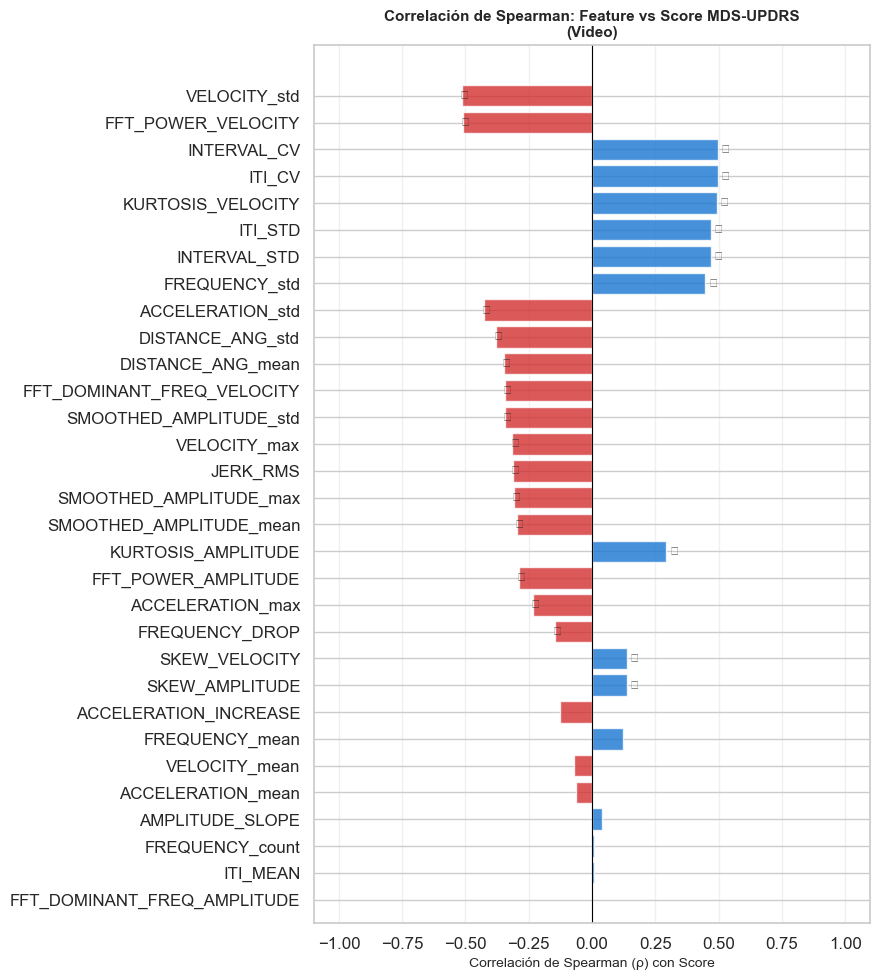

Top 5 correlaciones positivas (feature aumenta con severidad):
          feature      rho            p
      INTERVAL_CV 0.497139 3.901997e-15
           ITI_CV 0.497139 3.901997e-15
KURTOSIS_VELOCITY 0.495521 4.937847e-15
          ITI_STD 0.469720 1.791972e-13
     INTERVAL_STD 0.469720 1.791972e-13

Top 5 correlaciones negativas (feature disminuye con severidad):
           feature       rho            p
      VELOCITY_std -0.515184 2.591520e-16
FFT_POWER_VELOCITY -0.509959 5.777477e-16
  ACCELERATION_std -0.425556 4.335562e-11
  DISTANCE_ANG_std -0.380079 5.695788e-09
 DISTANCE_ANG_mean -0.349129 1.053889e-07
💾 Correlación Spearman guardada: ../results_files/analisis_estadistico/tablas/correlacion_spearman_video.csv


In [7]:
"""
============================================================================
CORRELACIÓN DE SPEARMAN — Features de video vs Score UPDRS
============================================================================
"""

if 'df_master' not in globals():
    csv_master = f"{Config.RUTA_SALIDA}/tablas/dataset_maestro_video.csv"
    if os.path.exists(csv_master):
        df_master = pd.read_csv(csv_master)
    else:
        raise RuntimeError('⚠️ Ejecuta la celda de carga de dataset primero.')

if not Config.FEATURES_ANALISIS:
    Config.FEATURES_ANALISIS = [c for c in df_master.columns if c not in ['ID', 'score']]

corr_rows = []
for feat in Config.FEATURES_ANALISIS:
    vals = df_master[feat].dropna()
    scores_v = df_master.loc[vals.index, 'score']
    if len(vals) > 5:
        rho, p = spearmanr(vals, scores_v)
        corr_rows.append({
            'feature': feat,
            'rho': rho,
            'p': p,
            'abs_rho': abs(rho)
        })

df_corr = pd.DataFrame(corr_rows).sort_values('abs_rho', ascending=False)

fig, ax = plt.subplots(figsize=(9, 10))
colores = ['#D32F2F' if r < 0 else '#1976D2' for r in df_corr['rho']]
ax.barh(df_corr['feature'][::-1], df_corr['rho'][::-1],
        color=colores[::-1], alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Spearman (ρ) con Score', fontsize=10)
ax.set_title('Correlación de Spearman: Feature vs Score MDS-UPDRS\n(Video)',
             fontsize=11, fontweight='bold')

for i, (_, row) in enumerate(df_corr[::-1].iterrows()):
    if row['p'] < Config.ALPHA:
        ax.text(row['rho'] + 0.01 * np.sign(row['rho']),
                i, '★', fontsize=9, va='center')

ax.grid(axis='x', alpha=0.3)
ax.set_xlim([-1.1, 1.1])
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/correlacion_spearman_video.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 correlaciones positivas (feature aumenta con severidad):")
print(df_corr[df_corr['rho'] > 0].head(5)[['feature', 'rho', 'p']].to_string(index=False))
print("\nTop 5 correlaciones negativas (feature disminuye con severidad):")
print(df_corr[df_corr['rho'] < 0].head(5)[['feature', 'rho', 'p']].to_string(index=False))

csv_corr = f"{Config.RUTA_SALIDA}/tablas/correlacion_spearman_video.csv"
df_corr.to_csv(csv_corr, index=False)
print(f"💾 Correlación Spearman guardada: {csv_corr}")

---
## CELDA 7 — Exportación final

In [8]:
"""
============================================================================
EXPORTACIÓN FINAL — Excel con todas las tablas
============================================================================
"""

if 'df_master' not in globals():
    csv_master = f"{Config.RUTA_SALIDA}/tablas/dataset_maestro_video.csv"
    df_master = pd.read_csv(csv_master)

if 'df_descriptivo' not in globals():
    csv_desc = f"{Config.RUTA_SALIDA}/tablas/descriptivo_video_por_score.csv"
    df_descriptivo = pd.read_csv(csv_desc)

if 'df_kw' not in globals():
    csv_kw = f"{Config.RUTA_SALIDA}/tablas/kruskal_wallis_video.csv"
    df_kw = pd.read_csv(csv_kw)

if 'df_posthoc' not in globals():
    csv_posthoc = f"{Config.RUTA_SALIDA}/tablas/posthoc_mannwhitney_video.csv"
    if os.path.exists(csv_posthoc):
        df_posthoc = pd.read_csv(csv_posthoc)
    else:
        df_posthoc = pd.DataFrame()

if 'df_corr' not in globals():
    csv_corr = f"{Config.RUTA_SALIDA}/tablas/correlacion_spearman_video.csv"
    df_corr = pd.read_csv(csv_corr)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
excel_path = f"{Config.RUTA_SALIDA}/tablas/analisis_estadistico_video_{timestamp}.xlsx"

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_master.drop(columns=['score'], errors='ignore').to_excel(
        writer, sheet_name='dataset_maestro', index=False
    )
    df_descriptivo.to_excel(writer, sheet_name='descriptivo_por_score', index=False)
    df_kw.sort_values('eta2', ascending=False).to_excel(writer, sheet_name='kruskal_wallis', index=False)

    if not df_posthoc.empty:
        df_posthoc[df_posthoc['sig_bonf'] == True].to_excel(
            writer, sheet_name='posthoc_mannwhitney', index=False
        )
    else:
        pd.DataFrame().to_excel(writer, sheet_name='posthoc_mannwhitney', index=False)

    df_corr.to_excel(writer, sheet_name='correlacion_spearman', index=False)

print(f"💾 Excel exportado: {excel_path}")

# ── Resumen ejecutivo ─────────────────────────────────────────────
print("\nRESUMEN EJECUTIVO — ANÁLISIS ESTADÍSTICO VIDEO")
print(f"Total muestras: {len(df_master)}")
print("Distribución de scores:")
print(df_master['score'].value_counts().sort_index().to_string())

n_features = len(Config.FEATURES_ANALISIS) if Config.FEATURES_ANALISIS else (
    len([c for c in df_master.columns if c not in ['ID', 'score']])
)
print(f"N features analizadas: {n_features}")

n_grande = int((df_kw['efecto'] == 'grande').sum()) if not df_kw.empty else 0
print(f"Features con efecto grande (KW): {n_grande}")

n_sig_spear = int((df_corr['p'] < Config.ALPHA).sum()) if not df_corr.empty else 0
print(f"Features significativas en Spearman (p<0.05): {n_sig_spear}")

top_eta = df_kw.nlargest(3, 'eta2')['feature'].tolist() if not df_kw.empty else []
top_rho = df_corr.nlargest(3, 'abs_rho')['feature'].tolist() if not df_corr.empty else []

print(f"Top 3 features por eta²: {top_eta}")
print(f"Top 3 features por |rho|: {top_rho}")
print(f"Ruta Excel: {excel_path}")

💾 Excel exportado: ../results_files/analisis_estadistico/tablas/analisis_estadistico_video_20260517_124014.xlsx

RESUMEN EJECUTIVO — ANÁLISIS ESTADÍSTICO VIDEO
Total muestras: 220
Distribución de scores:
score
0    68
1    96
2    33
3    23
N features analizadas: 31
Features con efecto grande (KW): 16
Features significativas en Spearman (p<0.05): 23
Top 3 features por eta²: ['VELOCITY_std', 'FFT_POWER_VELOCITY', 'INTERVAL_CV']
Top 3 features por |rho|: ['VELOCITY_std', 'FFT_POWER_VELOCITY', 'INTERVAL_CV']
Ruta Excel: ../results_files/analisis_estadistico/tablas/analisis_estadistico_video_20260517_124014.xlsx
